In [ ]:
# Sawyer Fuller 2025.08.22
# added non-teetering rotor simulation 2025.12.10
# effect of the counterbalance on spring constant of gimbal (changed gains to get 0.53 damping ratio) 2025.12.15

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import sympy as sym
!pip install control
import control as ct
from google.colab import files

sym.var(('J', 'd', 'b', 'c', 'g', 'm', 'k_1', 'k_a', 'k_2', 'k_3', 'lamda'))
class Bunch(): # copy-able bunch
    def copy(self):
        bunch2 = Bunch()
        bunch2.__dict__ = self.__dict__.copy()
        return bunch2

def to_numeric(sympy_array, params_bunch):
    return np.array(sympy_array.subs(params_bunch.__dict__), dtype=float)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.7 MB/s eta 0:00:00


**Free-flight dynamics**:

* drag force on the rotor is assumed to be $f_d = -bv_r = -b(v+d\dot \theta)\cos\theta\approx -b(v+d\dot \theta)$

| description |  equation..............................................................................|
| - | - |
| **body rotational moment balance** | $J\ddot \theta = \Sigma T = d f_d - c \dot \theta   + k_a(\phi - \theta)+mgd\sin(\phi-\theta)$|
| | $\approx -bdv-bd^2-c\dot\theta +k_a\phi - k_a\theta  + mgd\phi-mgd\theta$ |
| **body translational force balance** (body coordinates) | $m\dot v = \Sigma F = f_d + mg\sin\theta + mg\sin(\phi-\theta)$ |
| | $\approx -bv-bd\dot\theta + mg\phi$ |
| **rotor teetering dynamics** | $\dot \phi = k_1 \dot \theta  - k_2(\phi-\theta)$ |

**Remarks:**

* $k_a$ is elastic connection that drives main rotor to align to teetering rotation axis. Assumed to be zero.
* $c$ accounts for pitch and roll rotational damping of propeller.
* **no-flybar case**:
    * $k_1$ coupling set to zero because no feathering of main rotor due to flybar.
    * $k_2$ set to a high value: main rotor is not allowed to teeter. instead it stays coupled to main rotor axis
    * $c$ is set to be nonzero, with value measured by gimbal oscillation decay rate.
* **gimbal case**:
    * $v$ state and its effects are eliminated.
    * measured position of motor on gimbal specifies new $d$

## Free-flight dynamics linearization

In [ ]:
A = sym.Matrix(
     #theta   thdot   v     phi
    [[0,      1,       0,      0], # thetadot
     [(-m*g*d-k_a)/J,  -(d**2*b+c)/J, -d*b/J, (m*g*d+k_a)/J], # thetadotdot
     [0,      -b*d/m,  -b/m,   g], # vdot
     [k_2,    k_1,     0,      -k_2]]) # phidot
display(A)
#print(sym.latex(A))

Matrix([
[               0,               1,      0,               0],
[(-d*g*m - k_a)/J, (-b*d**2 - c)/J, -b*d/J, (d*g*m + k_a)/J],
[               0,          -b*d/m,   -b/m,               g],
[             k_2,             k_1,      0,            -k_2]])

## Gimbal dynamics linearization

In [ ]:
# gimbal case: no lateral velocity v state
Agimbal = sym.Matrix(
     #theta   thdot   phi
    [[0,      1,      0], # thetadot
     [(-m*g*d-k_a-k_3)/J,  -(d**2*b+c)/J, (m*g*d+k_a)/J], # thetadotdot
     [k_2,    k_1,   -k_2]]) # phidot
display(Agimbal)
#print(sym.latex(Agimbal))

Matrix([
[                     0,               1,               0],
[(-d*g*m - k_3 - k_a)/J, (-b*d**2 - c)/J, (d*g*m + k_a)/J],
[                   k_2,             k_1,            -k_2]])

In [ ]:
p = Bunch()
p.m_motor = 0.80e-3 # kg
p.m = 1.8e-3 # kg (2 grams)
p.l = 33e-3 # m length of rotor
p.h = 12e-3 # m height of motor
p.Jmotor = 1/12*p.m_motor*p.h**2 # J of a rod = 1/12 m l**2
Jcage = 2/5 * 0.4e-3 * 0.03**2  # kg m^2, model as a 400 mg, 3cm radius sphere
Jboom = 2 * 0.25e-3 * 0.021**2
# four possible cases of J, corresponding cage presence and whether roll or pitch J (no tail moment for roll)
p.J = p.Jmotor + Jcage + Jboom # with cage, pitch axis
#p.J = p.Jmotor + Jcage # with cage, roll axis
#p.J = p.Jmotor + Jboom # no cage, pitch axis
#p.J = 2 * p.Jmotor # no cage, roll axis
p.d = p.h/2 + 2e-3 # m, vert displacement between cm and cp
p.g = 9.81
print("p.Jmotor = ", p.Jmotor)
print("Jcage = ", Jcage)
print("Jboom = ", Jboom)
print("p.J = p.Jmotor + Jcage + Jboom = ", p.J)
print("p.J = p.Jmotor + Jcage = ", (p.Jmotor + Jcage))

# flybar/rotor parameters
p.k_1 = 0.1 # nM/(rad/s) coupling magnitude, flybar to rotor tilt.
p.k_a = 0   # spring constant coupling rotor axis to body z-axis
p.k_2 = 15  # speed to align rotor back to body, time constant = 1/k_2

# aerodynamics
alpha = 20 * np.pi/180 # rad, rotor angle of attack
Omega = 29674 * 2*np.pi/60 # rad/s, rotor angular vel
rcp = 2/3 * p.l/2 # m, radius of center of pressure
Cd = p.m * p.g / (2 * (Omega*rcp)**2 * np.sin(alpha)**2 * np.cos(alpha)) # [Ns^2m^-2] coefficient of drag for each blade.
p.c = 0 #1e-7 # Ns, rot damping. none because rotor is free to tilt
p.b = 8/np.pi*Cd*rcp*Omega*np.sin(alpha)**3# 3e-4 # Ns/m, blade-element approx
print(f'{p.b=}, {Cd=}, {p.b=}, {p.b=}, {p.b=}, ')

p.Jmotor =  9.6e-09
Jcage =  1.4400000000000002e-07
Jboom =  2.2050000000000002e-07
p.J = p.Jmotor + Jcage + Jboom =  3.7410000000000005e-07
p.J = p.Jmotor + Jcage =  1.5360000000000003e-07
p.b=np.float64(0.00023939777177354083), Cd=np.float64(6.87428510431441e-05), p.b=np.float64(0.00023939777177354083), p.b=np.float64(0.00023939777177354083), p.b=np.float64(0.00023939777177354083), 


In [ ]:
An = to_numeric(A, p)
np.linalg.eig(An).eigenvalues

array([-7.56244021+16.80199008j, -7.56244021-16.80199008j,
       -0.02453693 +1.48940974j, -0.02453693 -1.48940974j])

## Simulation of free-flight behavior

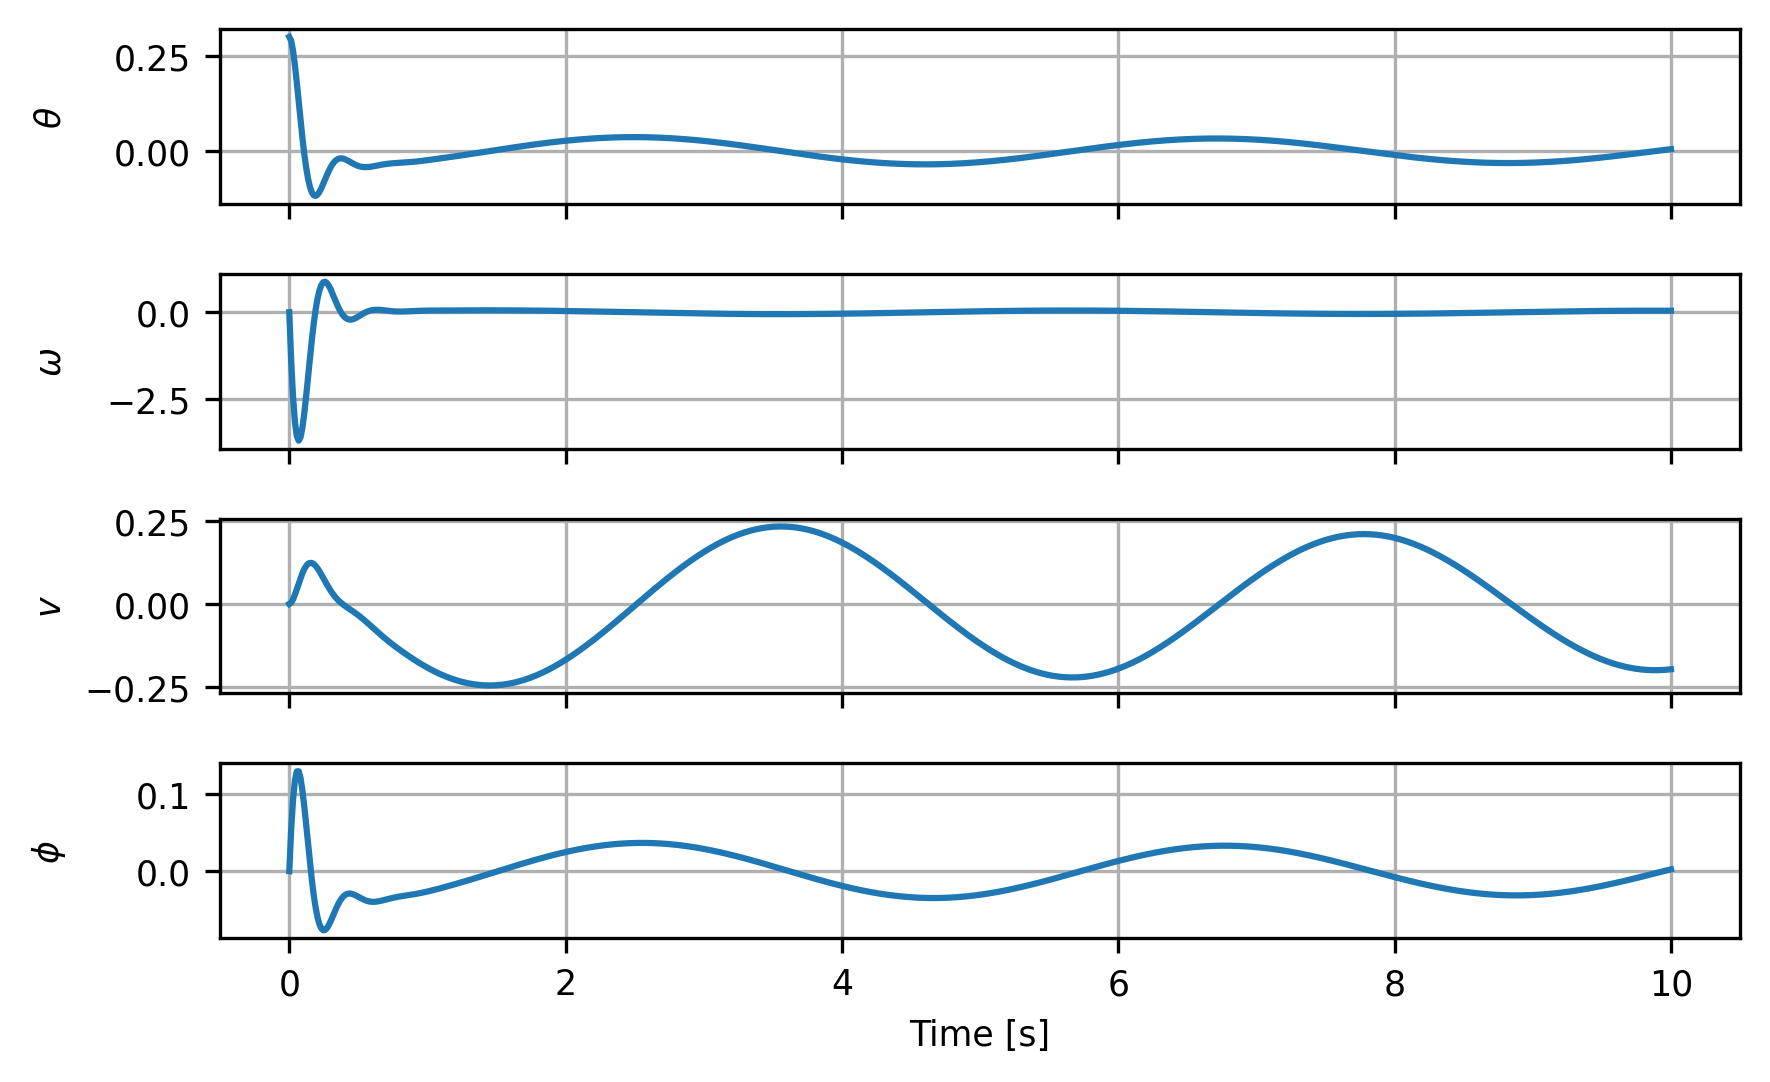

In [ ]:
def plotbox(x, z, theta, p, color='C0'):
    h = p.l/2; v = p.h/10
    R = np.array(((np.cos(theta), np.sin(theta)), (-np.sin(theta), np.cos(theta))))
    points = np.array(((h, h, -h, -h, h), (v, -v, -v, v, v)))
    rotated_points = R @ points #
    plt.plot(rotated_points[0,:] + x, rotated_points[1,:] + z, color=color, lw=1)

B, C, D = np.zeros(4), np.eye(4), 0 # state-space matrices
sys = ct.ss(An, B, C, D,
            outputs=[r'$\theta$',r'$\omega$','$v$',r'$\phi$'],
            name='flybar')
X0 = [0.3, 0, 0, 0] #theta   thdot   v     phi
fig = plt.figure(figsize=(6,4), dpi=300)
_response = ct.initial_response(sys, X0=X0, T=10)
_response.plot()
for ax in plt.gcf().get_axes():
  ax.grid()
plt.suptitle('')
if 0: # plot boxes
    theta, omega, v, phi = _response.y
    dt = _response.t[1] - _response.t[0] # time base
    x = np.cumsum(v) * dt # compute x by integration and (convert from m to mm?)
    n = len(theta);
    cmap = mpl.colormaps['plasma']
    for idx in range(0, n, 10):
        plotbox(x[idx], 0, theta[idx], p, color=cmap(idx/n))
    plt.axis('equal')
    #plt.ylim(-0.01, 0.01)  # Set y-axis limits
    #plt.gca().set_aspect('auto')  # Allow aspect ratio adjustment
    plt.xlabel('x (m)')
    plt.ylabel('z (m)');
#plt.show()
# plt.savefig('Free_flight_simulation.pdf')
# files.download('Free_flight_simulation.pdf')

[-7.56244021+16.80199008j -7.56244021-16.80199008j
 -0.02453693 +1.48940974j -0.02453693 -1.48940974j]


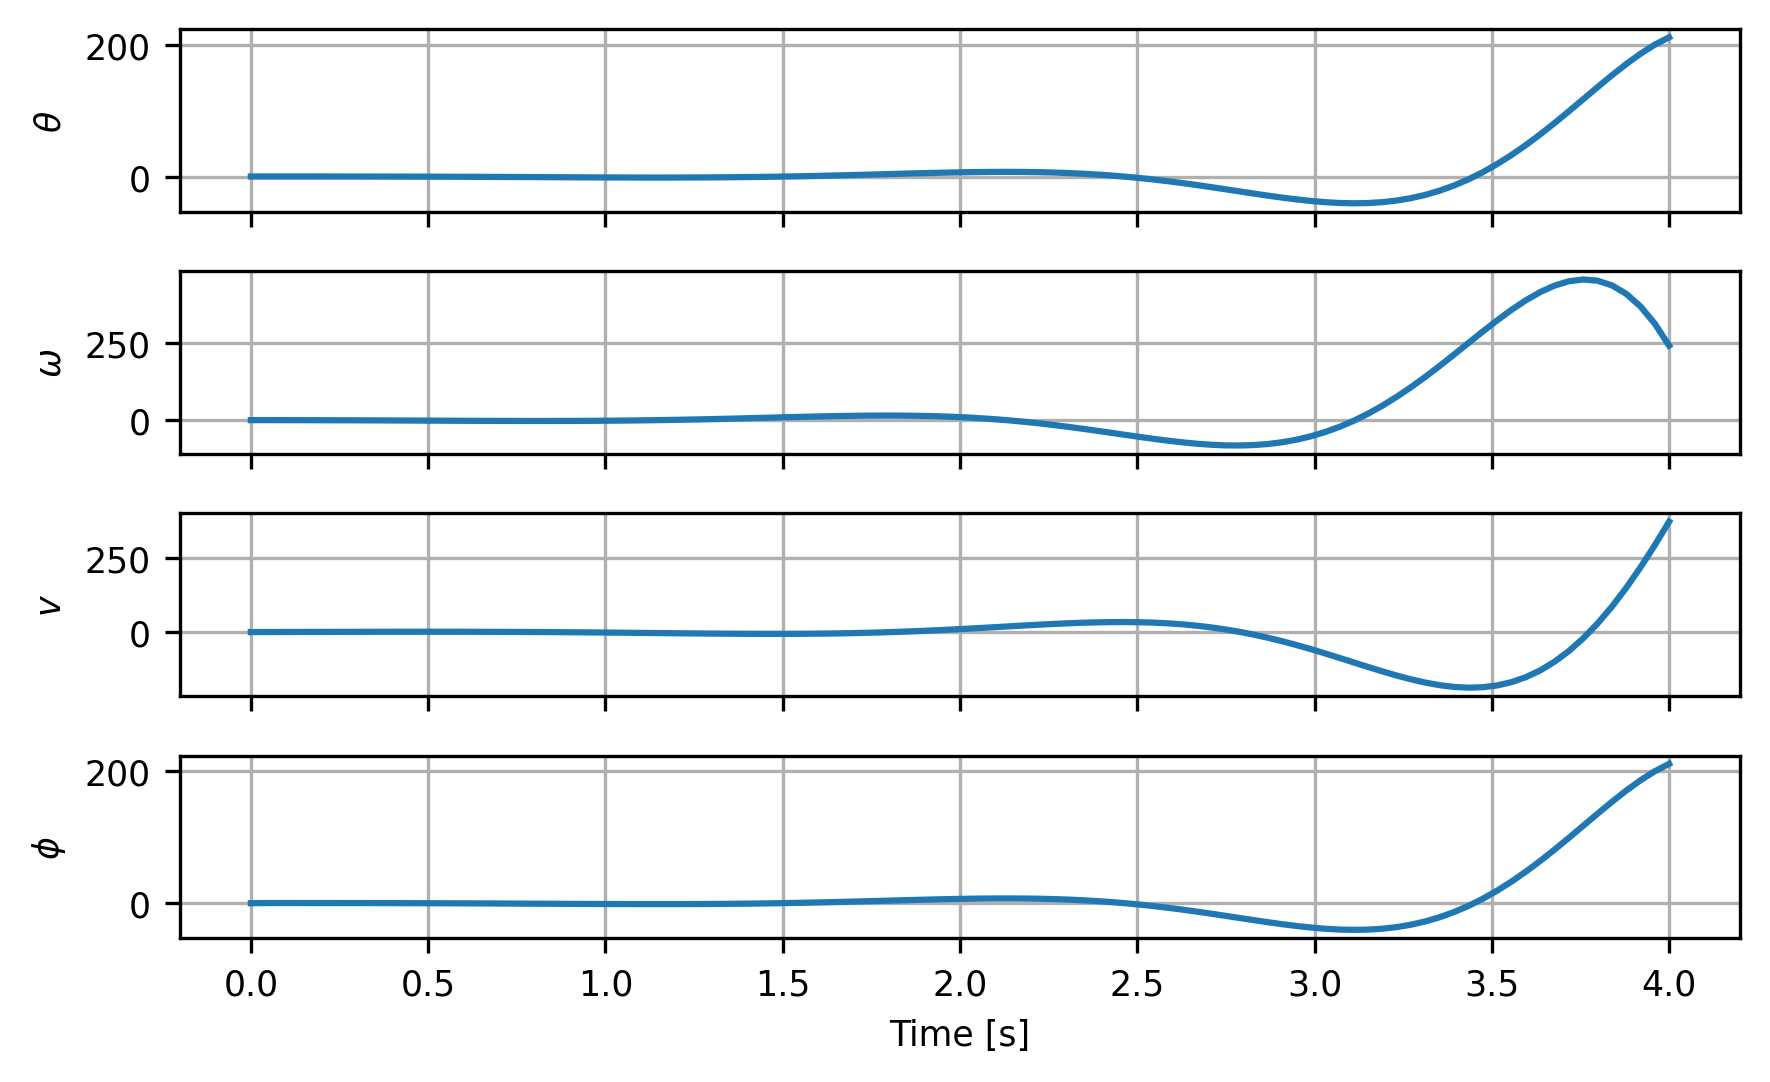

In [ ]:
#no flybar case
p_noflybar = p.copy()
p_noflybar.k_1 = 0 # no coupling from flybar to rotor
p_noflybar.k_2 = 1e5 # large -> stiff connection -> rotor follows body
p_noflybar.c = 5e-8 # to match decay rate of gimbal experiment
A_noflybar_n = to_numeric(A, p_noflybar)
print(np.linalg.eig(An).eigenvalues)
fig = plt.figure(figsize=(6,4), dpi=300)
sys_noflybar = ct.ss(A_noflybar_n, B, C, D,
             outputs=[r'$\theta$',r'$\omega$','$v$',r'$\phi$'],
             name='no flybar')
ct.initial_response(sys_noflybar, X0=X0, T=4).plot()
for _ax in plt.gcf().get_axes():
  _ax.grid();
plt.suptitle('')
plt.savefig('Free_flight_noflybar.pdf')
#files.download('Free_flight_noflybar.pdf')
plt.show()


## Gimbal response plot

m_ring=0.00012088848531013524 kg
pgimbal.k_3=2.721408225159553e-06 Nm/rad
[-6.34545317+21.94331755j -6.34545317-21.94331755j
 -2.3161811  +0.j        ]
[-9.99999948e+04+0.j         -7.46290967e-01+8.94490096j
 -7.46290967e-01-8.94490096j]


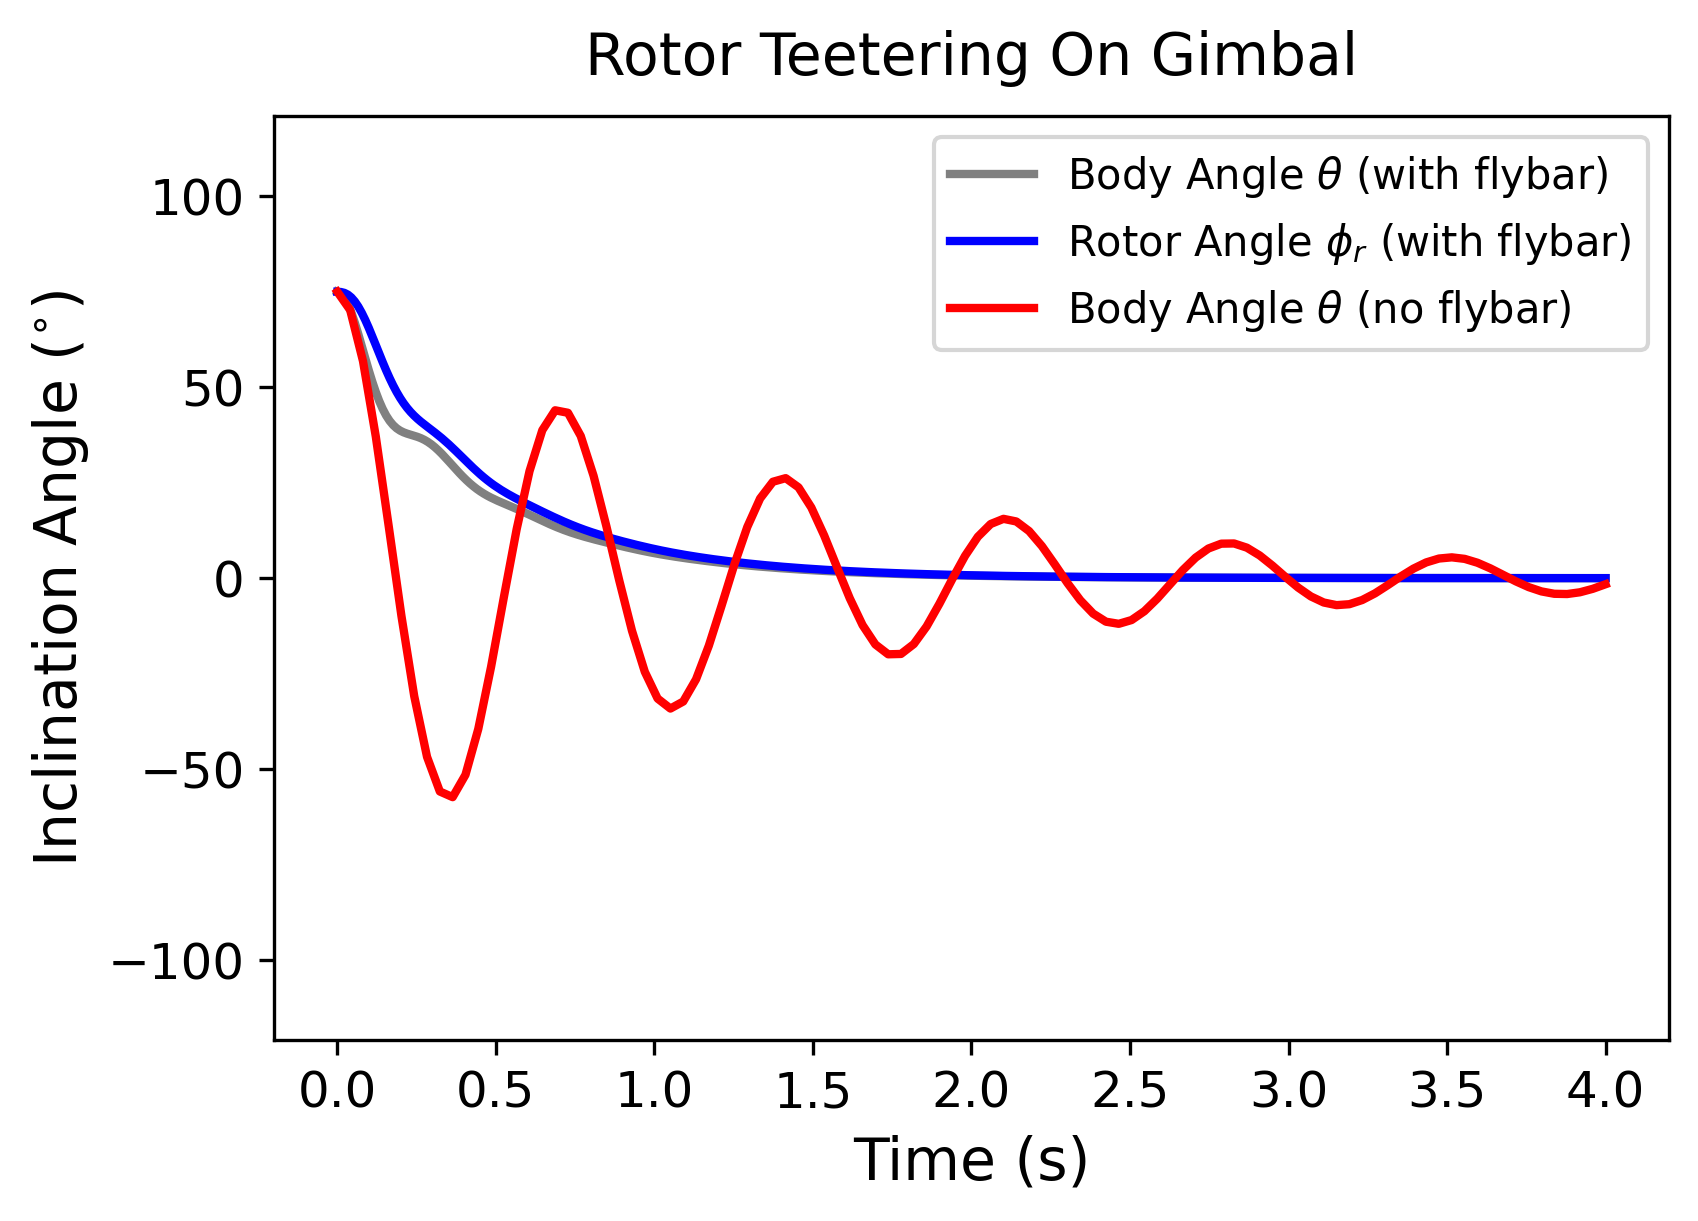

pgimbal.J=3.377769706202705e-08


In [ ]:
# gimbal stiffness k_3 calculations
# calculate moment of inertia of gimbal ring
rho_fr4_gcm3 = 1.850 # g/cm3, density of FR4
rho_fr4 = rho_fr4_gcm3 * 100**3/1000 # kg/m3
r_ring = 2e-2 # m, radius of ring
w_ring = 2e-3 # m, width of ring
t_ring = 260e-6 # m, thickness of ring (two layers of 125 um FR4 + adhesive)
m_ring = 2 * np.pi * r_ring * w_ring * t_ring * rho_fr4 # mass of ring [kg]
print(f'{m_ring=} kg') # ~120 mg, seems reasonable
Jgimbal =  1 / 2 * m_ring * r_ring**2 # it is about same as 4mm motor

# match observed frequency on gimbal with spinning prop
wn = 2 * np.pi /.7 # rad/s, natural frequency
pgimbal = p.copy()
pgimbal.J = p.Jmotor + Jgimbal
pgimbal.k_3 = pgimbal.J * wn**2 # Nm/rad, nat freq wn = sqrt(k4/J)
pgimbal.d = p.h/2 - 5e-3 # distance from rotation axis to center of pressure
print(f'{pgimbal.k_3=} Nm/rad')

Agimbal_n = to_numeric(Agimbal, pgimbal)
print(np.linalg.eig(Agimbal_n).eigenvalues)
sys_gimbal = ct.ss(Agimbal_n, np.zeros(3), np.eye(3), 0,
                   outputs=[r'$	heta$',r'$	au$',r'$ii$'],
                   name='gimbal flybar')
X0_gimbal = [75/180*np.pi, 0, 75/180*np.pi] #theta thdot phi
_response = ct.initial_response(sys_gimbal, X0=X0_gimbal, T=4)
plt.figure(figsize=(6,4), dpi=300)
plt.plot(_response.time, _response.x[0,:] * 180 / np.pi, color='grey',
         label=r'Body Angle $\theta$ (with flybar)', linewidth=2, zorder=1)
plt.plot(_response.time, _response.x[2,:] * 180 / np.pi, color='blue',
        label=r'Rotor Angle $\phi_r$ (with flybar)', linewidth=2, zorder=2)

pgimbal_noflybar = p_noflybar.copy()
pgimbal_noflybar.J = pgimbal.J
pgimbal_noflybar.k_3 = pgimbal.k_3 # Nm/rad
pgimbal_noflybar.d = pgimbal.d # m

Agimbal_noflybar_n = to_numeric(Agimbal, pgimbal_noflybar)
print(np.linalg.eig(Agimbal_noflybar_n).eigenvalues)
sys_gimbal_noflybar = ct.ss(Agimbal_noflybar_n, np.zeros(3), np.eye(3), 0,
                            outputs=[r'$\theta$',r'$	au$',r'$ii$'],
                            name='gimbal no flybar')
_response = ct.initial_response(sys_gimbal_noflybar, X0=X0_gimbal, T=4)
#for _ax in plt.gcf().get_axes(): _ax.grid()
plt.plot(_response.time, _response.x[0,:] * 180 / np.pi, color='red',
        label=r'Body Angle $\theta$ (no flybar)', linewidth=2, zorder=3)
plt.legend()
plt.ylim(-121, 121)
plt.tick_params(axis='both', which='major', labelsize=12) # Increase tick label font size
plt.ylabel(r'Inclination Angle $(^{\circ})$', fontsize=14) # Increase y-label font size
plt.xlabel('Time (s)', fontsize=14) # Increase x-label font size
plt.title('Rotor Teetering On Gimbal', fontsize=14, pad=10)
plt.savefig('Rotor_Teetering_on_Gimbal.pdf')
#files.download('Rotor_Teetering_on_Gimbal.pdf')
plt.show()
print(f'{pgimbal.J=}')

Text(0.5, 0.98, '')

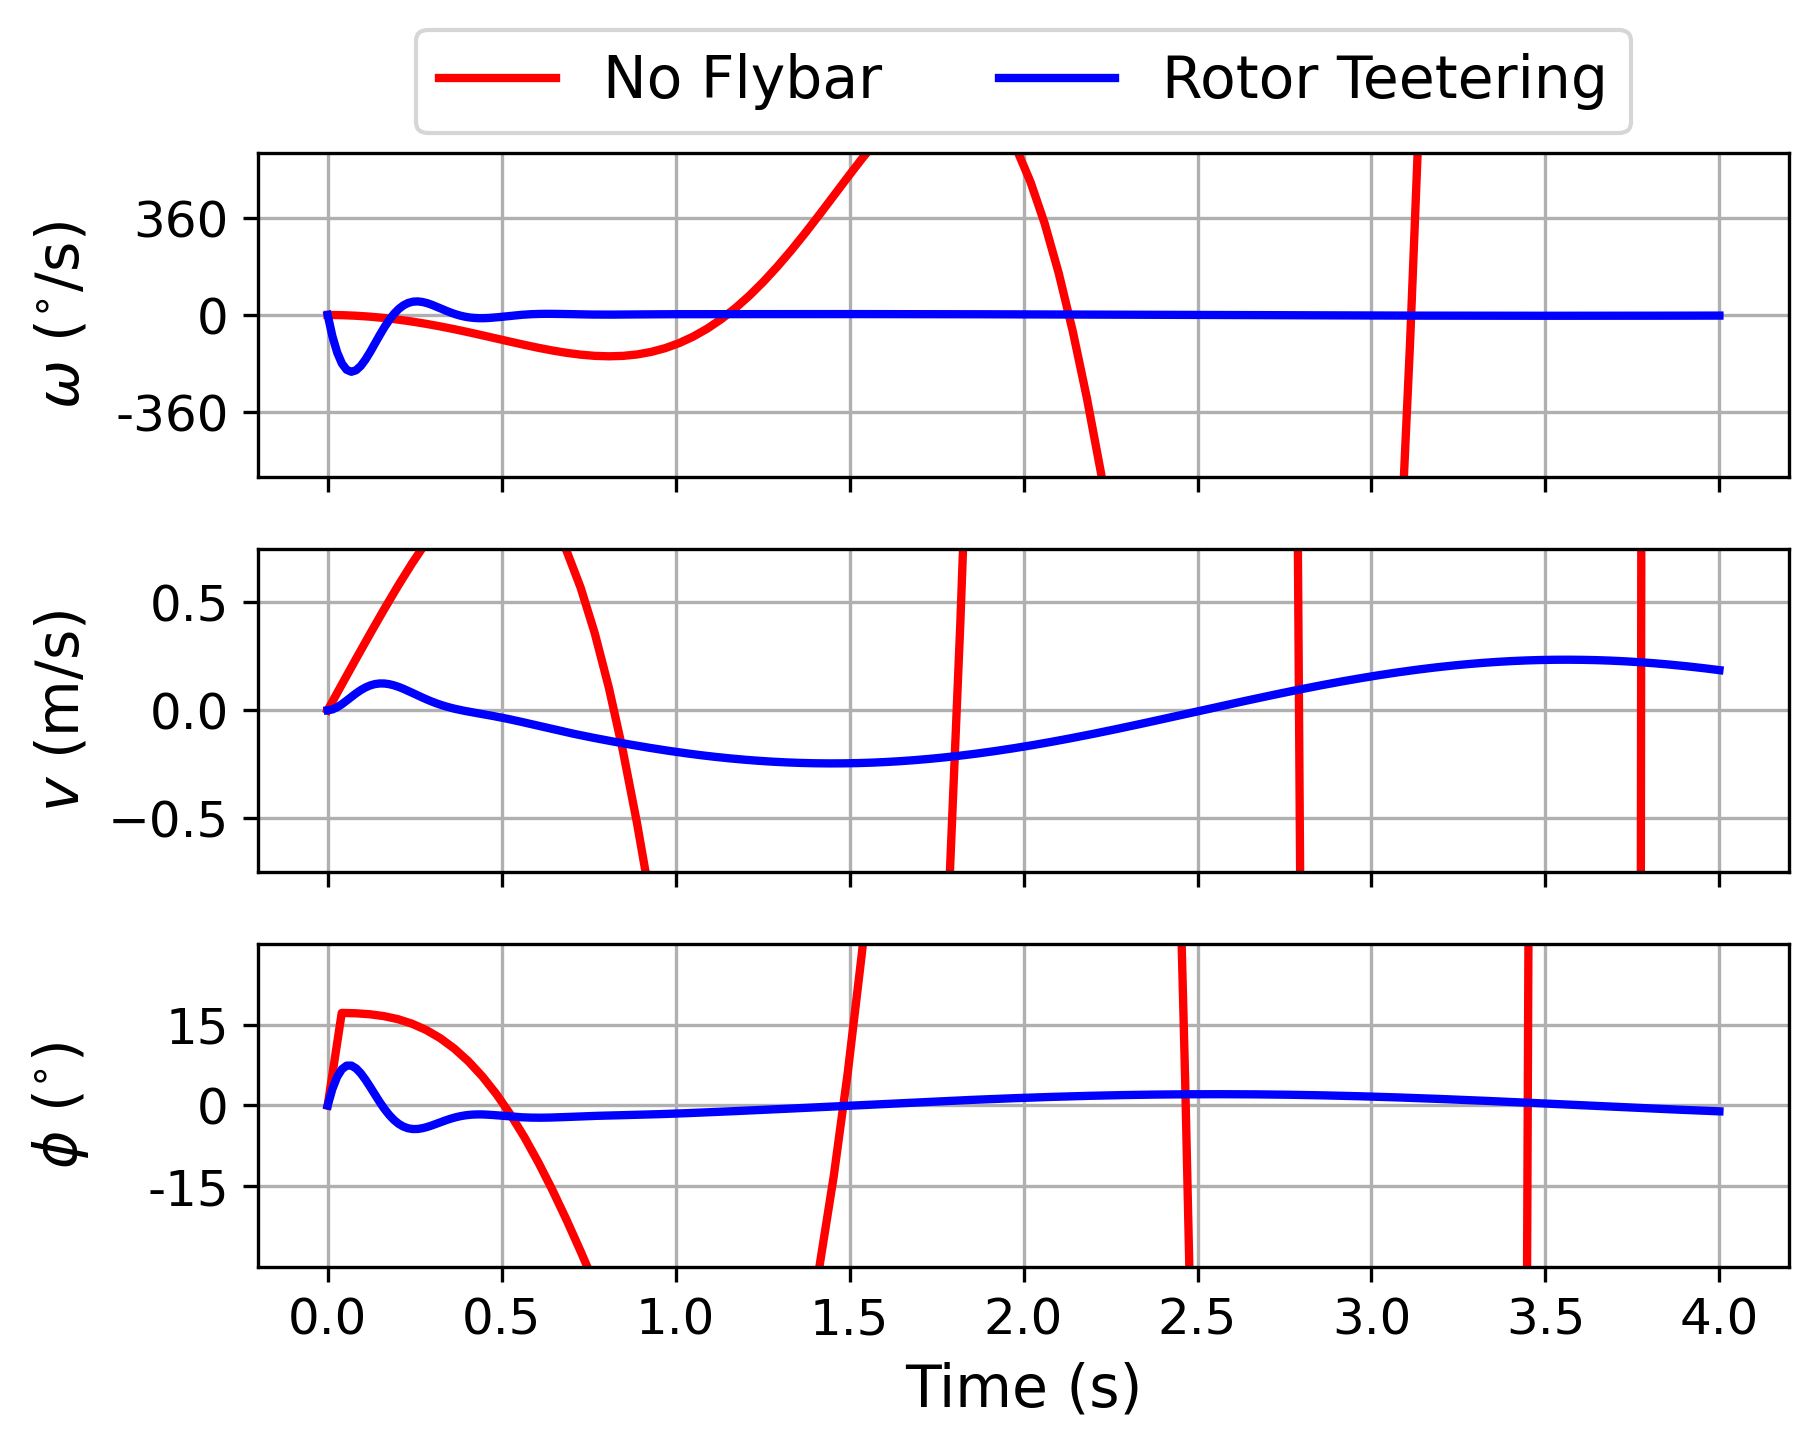

In [ ]:
fig = plt.figure(figsize=(6,6), dpi=300)
response_noflybar = ct.initial_response(sys_noflybar, X0=X0, T=4).plot()
response_flybar = ct.initial_response(sys, X0=X0, T=4).plot()
deg_formatter = FuncFormatter(lambda y, _: f'{np.rad2deg(y):.0f}')
degps_formatter = FuncFormatter(lambda y, _: f'{np.rad2deg(y):.0f}')

# removes the theta subplot
axs = plt.gcf().get_axes()
axs[0].remove()

for i, _ax in enumerate(plt.gcf().get_axes()):
    lines = _ax.get_lines()
    for line in lines:
      line.set_linewidth(2)
    if len(lines) >= 2:
        lines[0].set_color('red')
        lines[1].set_color('blue')
    if i == 0:
        _ax.legend(
            ["No Flybar", "Rotor Teetering"],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.4),
            ncol=2, fontsize=14, borderaxespad=0.1
        )
    #     _ax.set_ylim(np.deg2rad(-45), np.deg2rad(45))
    #     _ax.set_yticks(np.deg2rad(np.arange(-30,31,30)))
    #     _ax.yaxis.set_major_formatter(deg_formatter)
    #     _ax.set_ylabel(r'$\theta$ ($^{\circ}$)')
    # elif i == 1:
        _ax.set_ylim(np.deg2rad(-600), np.deg2rad(600))
        _ax.set_yticks(np.deg2rad(np.arange(-360,361,360)))
        _ax.yaxis.set_major_formatter(degps_formatter)
        _ax.set_ylabel(r'$\omega$ ($^{\circ}$/s)')
    elif i == 1:
        _ax.set_ylim(-0.75, 0.75)
        _ax.set_ylabel(r'$v$ (m/s)')
    elif i == 2:
        _ax.set_ylim(np.deg2rad(-30), np.deg2rad(30))
        _ax.set_yticks(np.deg2rad(np.arange(-15,16,15)))
        _ax.yaxis.set_major_formatter(deg_formatter)
        _ax.set_ylabel(r'$\phi$ ($^{\circ}$)', fontsize=14)
        _ax.set_xlabel("Time (s)", fontsize=14)
    _ax.grid()
    _ax.tick_params(axis='both', which='major', labelsize=12)
    _ax.set_ylabel(_ax.get_ylabel(), fontsize=14)

plt.suptitle('')
#plt.savefig('/content/gdrive/My Drive/Coin-copter/Simulations/flybar_comparison.pdf')

Text(0.5, 0.98, '')

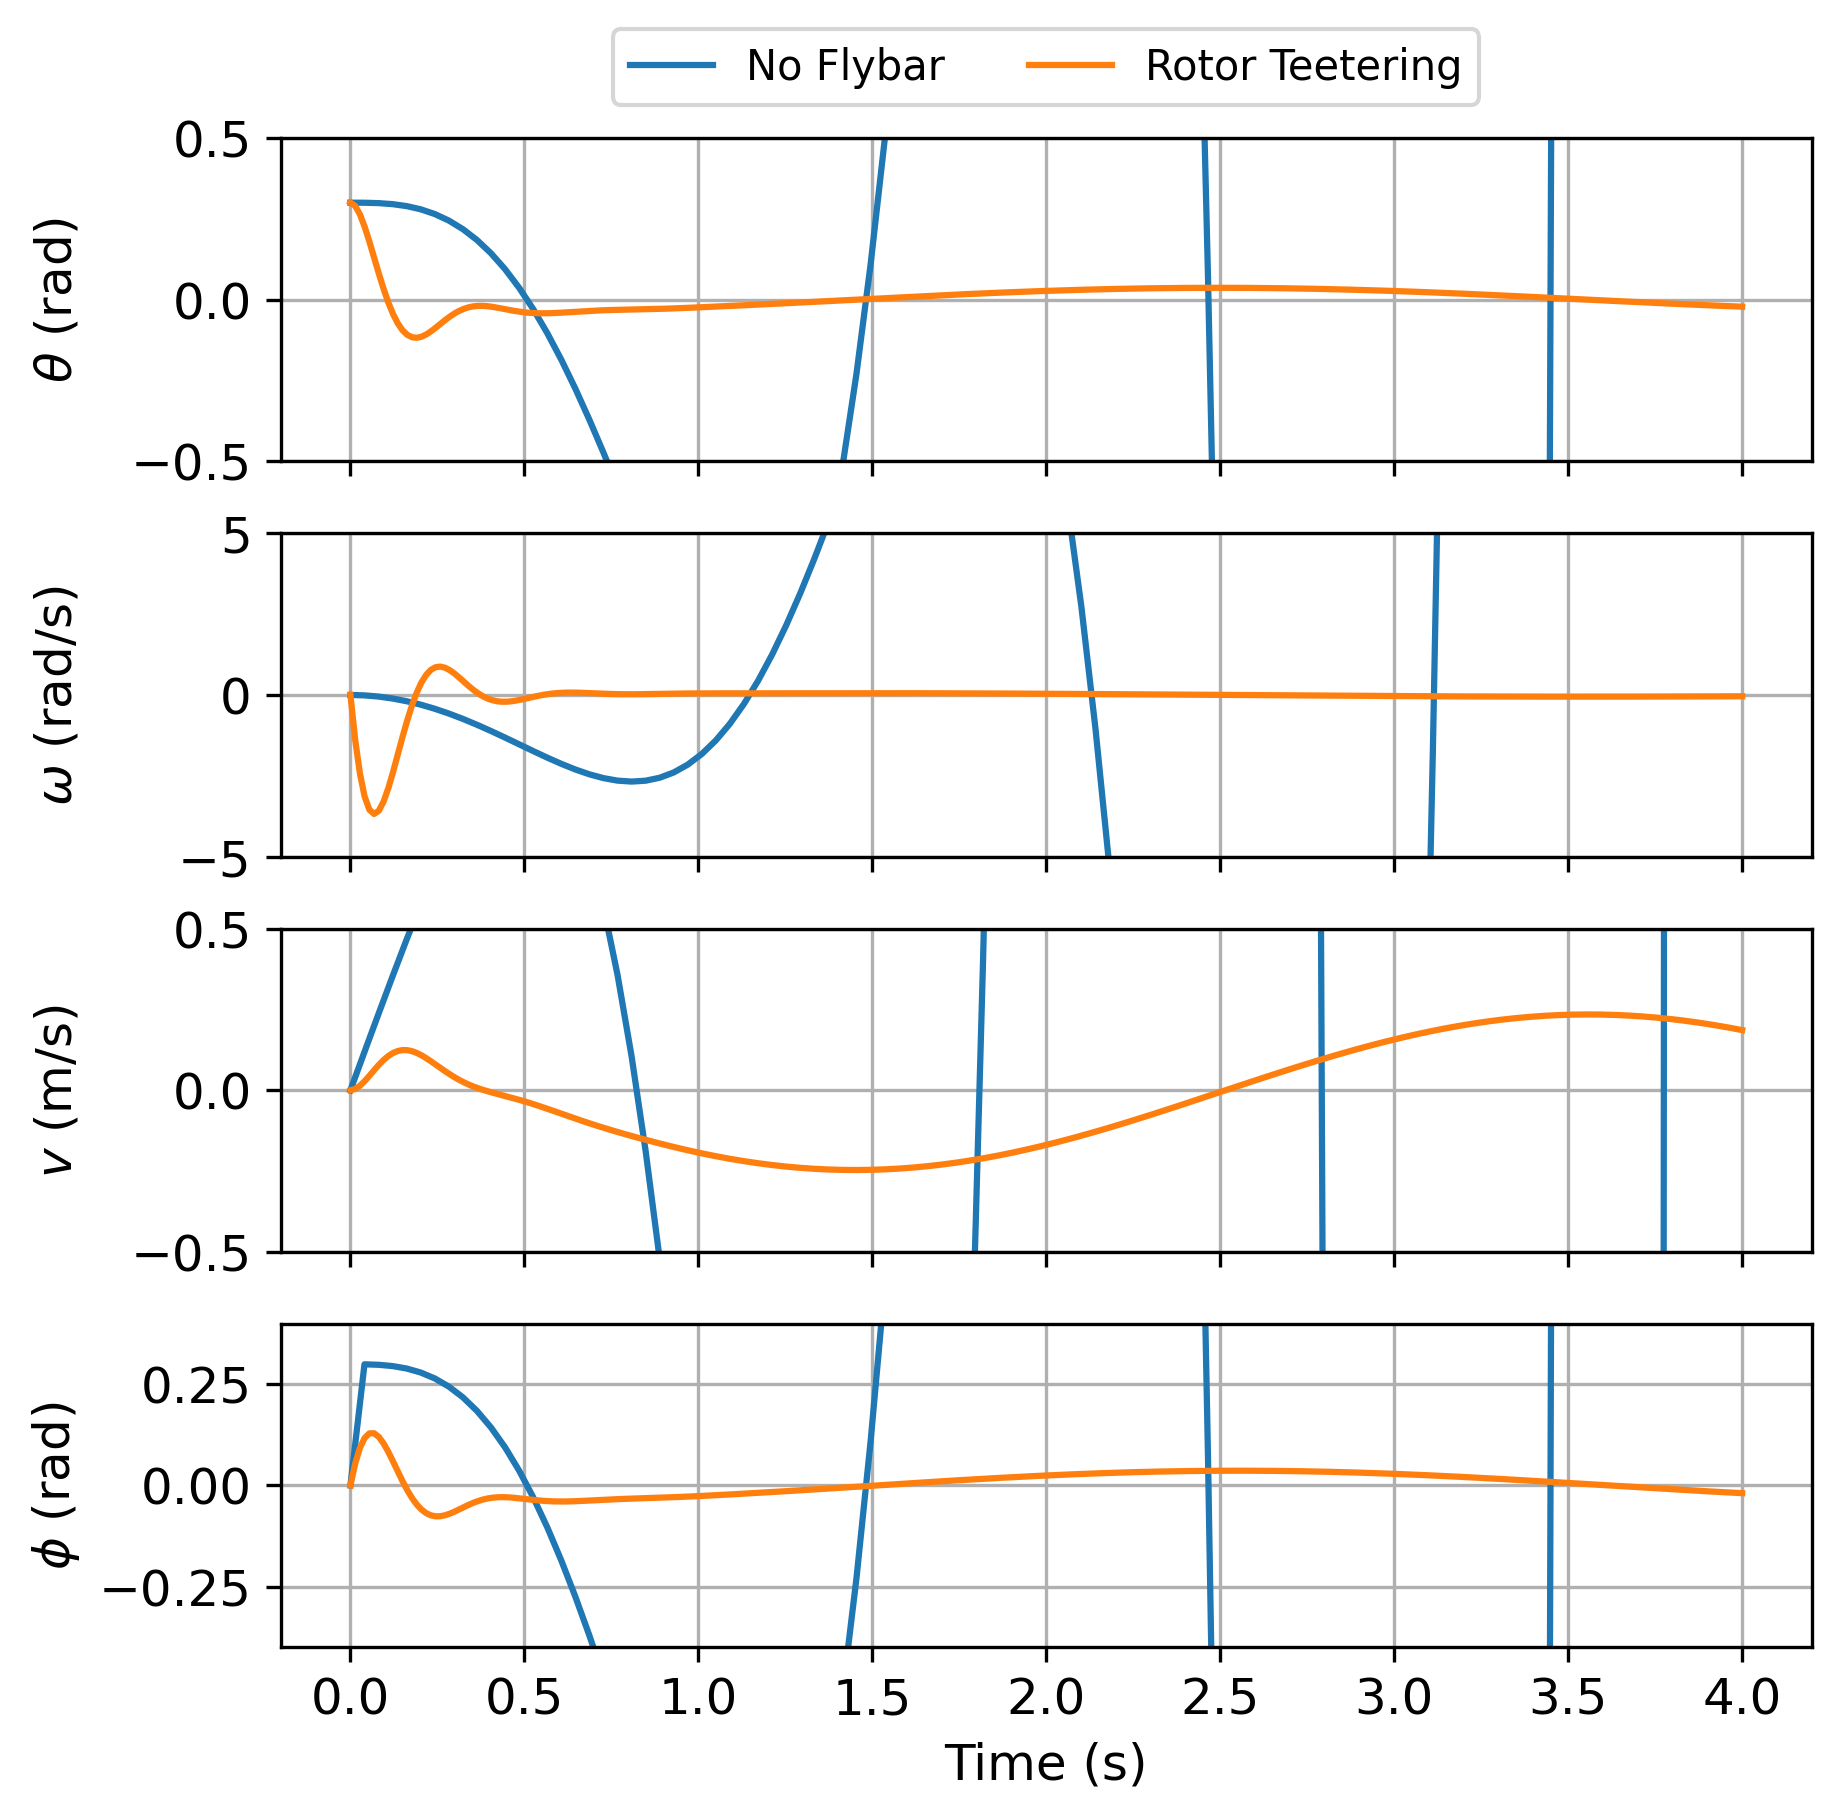

In [ ]:
################################################
############### SAWYER'S OLD CODE ##############
################################################

fig = plt.figure(figsize=(6,6), dpi=300)
ct.initial_response(sys_noflybar, X0=X0, T=4).plot()
ct.initial_response(sys, X0=X0, T=4).plot()
# KYLE: convert from radians to degrees & degrees/sec
for i, _ax in enumerate(plt.gcf().get_axes()):
  if i == 0:
    _ax.legend(["No Flybar", "Rotor Teetering"], loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=2)
    _ax.set_ylim(-.5, .5) # Example limits for theta
    _ax.set_ylabel(r'$\theta$ (rad)')
  elif i == 1:
    _ax.set_ylim(-5, 5) # Example limits for omega
    _ax.set_ylabel(r'$\omega$ (rad/s)')
  elif i == 2:
    _ax.set_ylim(-0.5, 0.5) # Example limits for v
    _ax.set_ylabel(r'$v$ (m/s)')
  elif i == 3:
    _ax.set_ylim(-0.4, 0.4) # Example limits for phi
    _ax.set_ylabel(r'$\phi$ (rad)')
    _ax.set_xlabel("Time (s)", fontsize=12)
  _ax.grid();
  # Increase font size of tick labels
  _ax.tick_params(axis='both', which='major', labelsize=12)
  # Increase font size of axis labels
  #_ax.set_xlabel(_ax.get_xlabel(), fontsize=12)
  _ax.set_ylabel(_ax.get_ylabel(), fontsize=12)
plt.suptitle('')
#plt.savefig('/content/gdrive/My Drive/Coin-copter/Simulations/flybar_comparison.pdf')

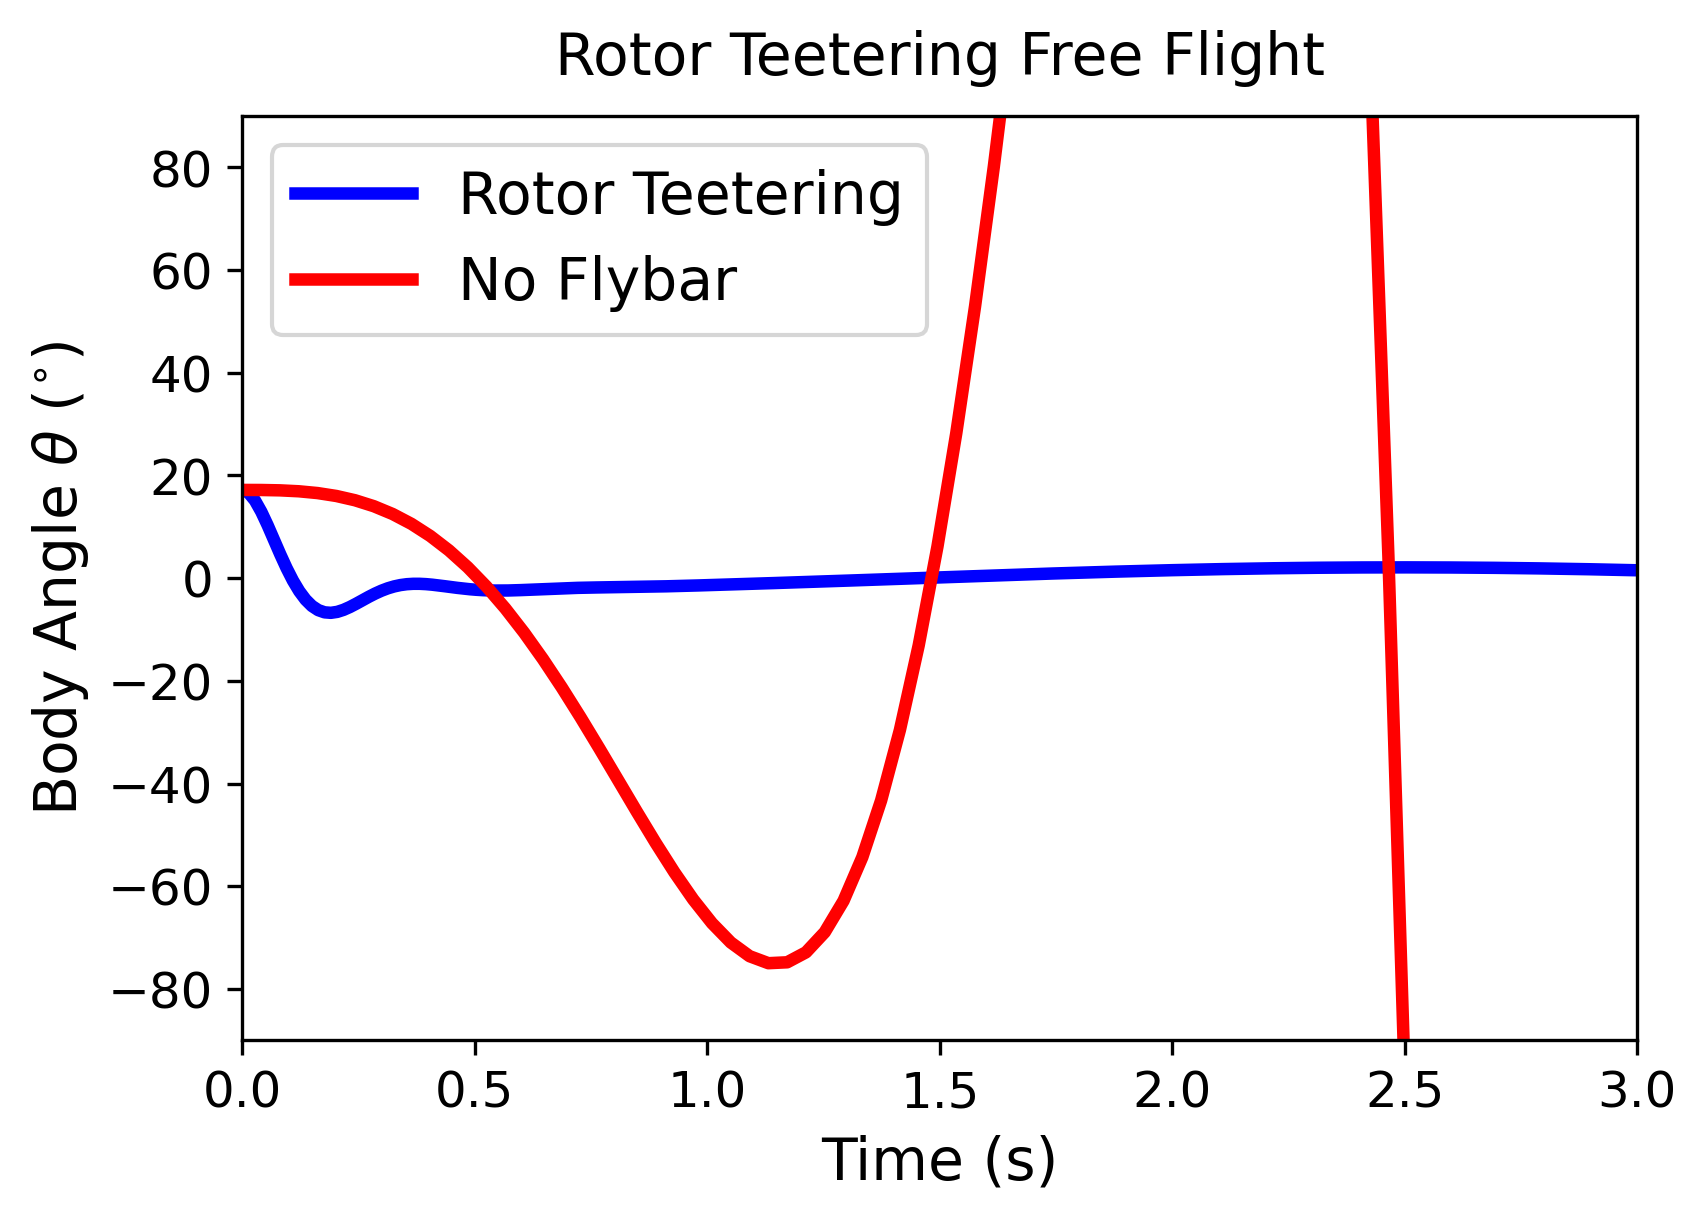

In [ ]:
fig = plt.figure(figsize=(6,4), dpi=300) # Adjust figure size for a single plot
ax = fig.add_subplot(111) # Add a single subplot

# Get response data for both cases
flybarless_response = ct.initial_response(sys_noflybar, X0=X0, T=4)
flybar_response = ct.initial_response(sys, X0=X0, T=4)

# Plot theta for 'Flybar' in degrees
ax.plot(flybar_response.time, flybar_response.x[0,:] * 180 / np.pi, color='blue', linewidth=3, label='Rotor Teetering')
# Plot theta for 'No Flybar' in degrees
ax.plot(flybarless_response.time, flybarless_response.x[0,:] * 180 / np.pi, color='red', linewidth=3, label='No Flybar')
plt.title('Rotor Teetering Free Flight', fontsize=14, pad=10)
ax.legend(loc='upper left', fontsize=14, facecolor='white') # Increase legend font size and set background
ax.set_xlim(0, 3) # Show only the first X second(s)
ax.set_ylim(-90, 90) # Example limits for theta in degrees, adjust as needed
ax.set_ylabel(r'Body Angle $\theta$ $(^{\circ})$', fontsize=14) # Increase y-label font size
ax.set_xlabel('Time (s)', fontsize=14) # Increase x-label font size
# ax.grid()
ax.tick_params(axis='both', which='major', labelsize=12) # Tick label font size (kept at 12)
plt.show()

# IROS2023 version of coincopter (no teetering rotor)
Definitions: (note that some symbols are reused from teetering rotor model but are different)
* $\phi$ : tilt of the flybar (rather than the rotor teeter angle)
* $k_1$ is flybar feathering effect, a torque on the body (rather than rotor only, because rotor is fixed to body) that is proportional to inclination difference between flybar and body
* $k_2$ is rate of alignment of flybar to body (rather than main rotor to body)

first, add the constants that we calculated to the set of simulation parameters

## Nonlinear dynamics
<img src="https://drive.google.com/uc?id=1DpAPIfGynpuwQbBP4JvsMRdBfMeCxOXT" width="300">

| description |  equation for nonlinear dynamics |
| - | - |
| **body translational force balance** (body coordinates)| $m\dot v = \Sigma f $ |
| | $~~~~~ = f_d + mg\sin\theta$, where (linearized) $f_d = -bv_r = -b(v+d\dot \theta) $  |
| **body rotational moment balance** | $J\ddot \theta = \Sigma T$ |
| | $ ~~~~~ = d f_d - c \dot \theta   + k_1(\phi - \theta)$|
| **flybar dynamics** (aligns flybar to body) | $\dot \phi = -k_2(\phi-\theta)$ |


### linearization
$\dot x = Ax$ where state $x = [\theta,~\dot \theta,~v,~\phi]^T$

In [ ]:
A_noteeter = sym.Matrix(
     #theta   thdot   v     phi
    [[0,      1,      0,      0], # thetadot
     [-k_1/J, -(d**2*b+c)/J, -d*b/J, k_1/J], # thetadotdot
     [g,      -b*d/m,      -b/m,   0], # vdot
     [k_2,    0,      0,      -k_2]]) # phidot
display(A_noteeter)
print(sym.latex(A_noteeter))

Matrix([
[     0,               1,      0,     0],
[-k_1/J, (-b*d**2 - c)/J, -b*d/J, k_1/J],
[     g,          -b*d/m,   -b/m,     0],
[   k_2,               0,      0,  -k_2]])

\left[\begin{matrix}0 & 1 & 0 & 0\\- \frac{k_{1}}{J} & \frac{- b d^{2} - c}{J} & - \frac{b d}{J} & \frac{k_{1}}{J}\\g & - \frac{b d}{m} & - \frac{b}{m} & 0\\k_{2} & 0 & 0 & - k_{2}\end{matrix}\right]


rigid rotor on gimbal

* remove v from states. Now state is $[\theta, \dot\theta, \phi]^T$
* include the effect of restoring stiffness $k_3$ due to flexures and CM  being below the rotation axis (pendulum restoring torque)
* include effect of added $J$ from pendulum weight

In [ ]:
Agimbal_noteeter = sym.Matrix(
     #theta   thdot   phi
    [[0,      1,      0], # thetadot
     [-(k_1+k_3)/J, -(d**2*b+c)/J, k_1/J], # thetadotdot
     [k_2,    0,   -k_2]]) # phidot
display(Agimbal_noteeter)
print(sym.latex(Agimbal_noteeter))

Matrix([
[             0,               1,     0],
[(-k_1 - k_3)/J, (-b*d**2 - c)/J, k_1/J],
[           k_2,               0,  -k_2]])

\left[\begin{matrix}0 & 1 & 0\\\frac{- k_{1} - k_{3}}{J} & \frac{- b d^{2} - c}{J} & \frac{k_{1}}{J}\\k_{2} & 0 & - k_{2}\end{matrix}\right]


Obtain $k$ values from gimbal experiments.

eigenvalues: [-70.56177127 +0.j          -4.87286668+17.00677883j
  -4.87286668-17.00677883j]
    Eigenvalue (pole)       Damping     Frequency
               -70.56             1         70.56
    -4.873    +17.01j        0.2754         17.69
    -4.873    -17.01j        0.2754         17.69
angle comparison from video. gimbal angle=9.186454685637678, flybar angle=20.148337361478386, difference: 10.961882675840709
eigenvalues: [-1.00000000e+05 +0.j         -1.53752313e-01+16.61407697j
 -1.53752313e-01-16.61407697j]
    Eigenvalue (pole)       Damping     Frequency
               -1e+05             1         1e+05
   -0.1538    +16.61j      0.009254         16.61
   -0.1538    -16.61j      0.009254         16.61


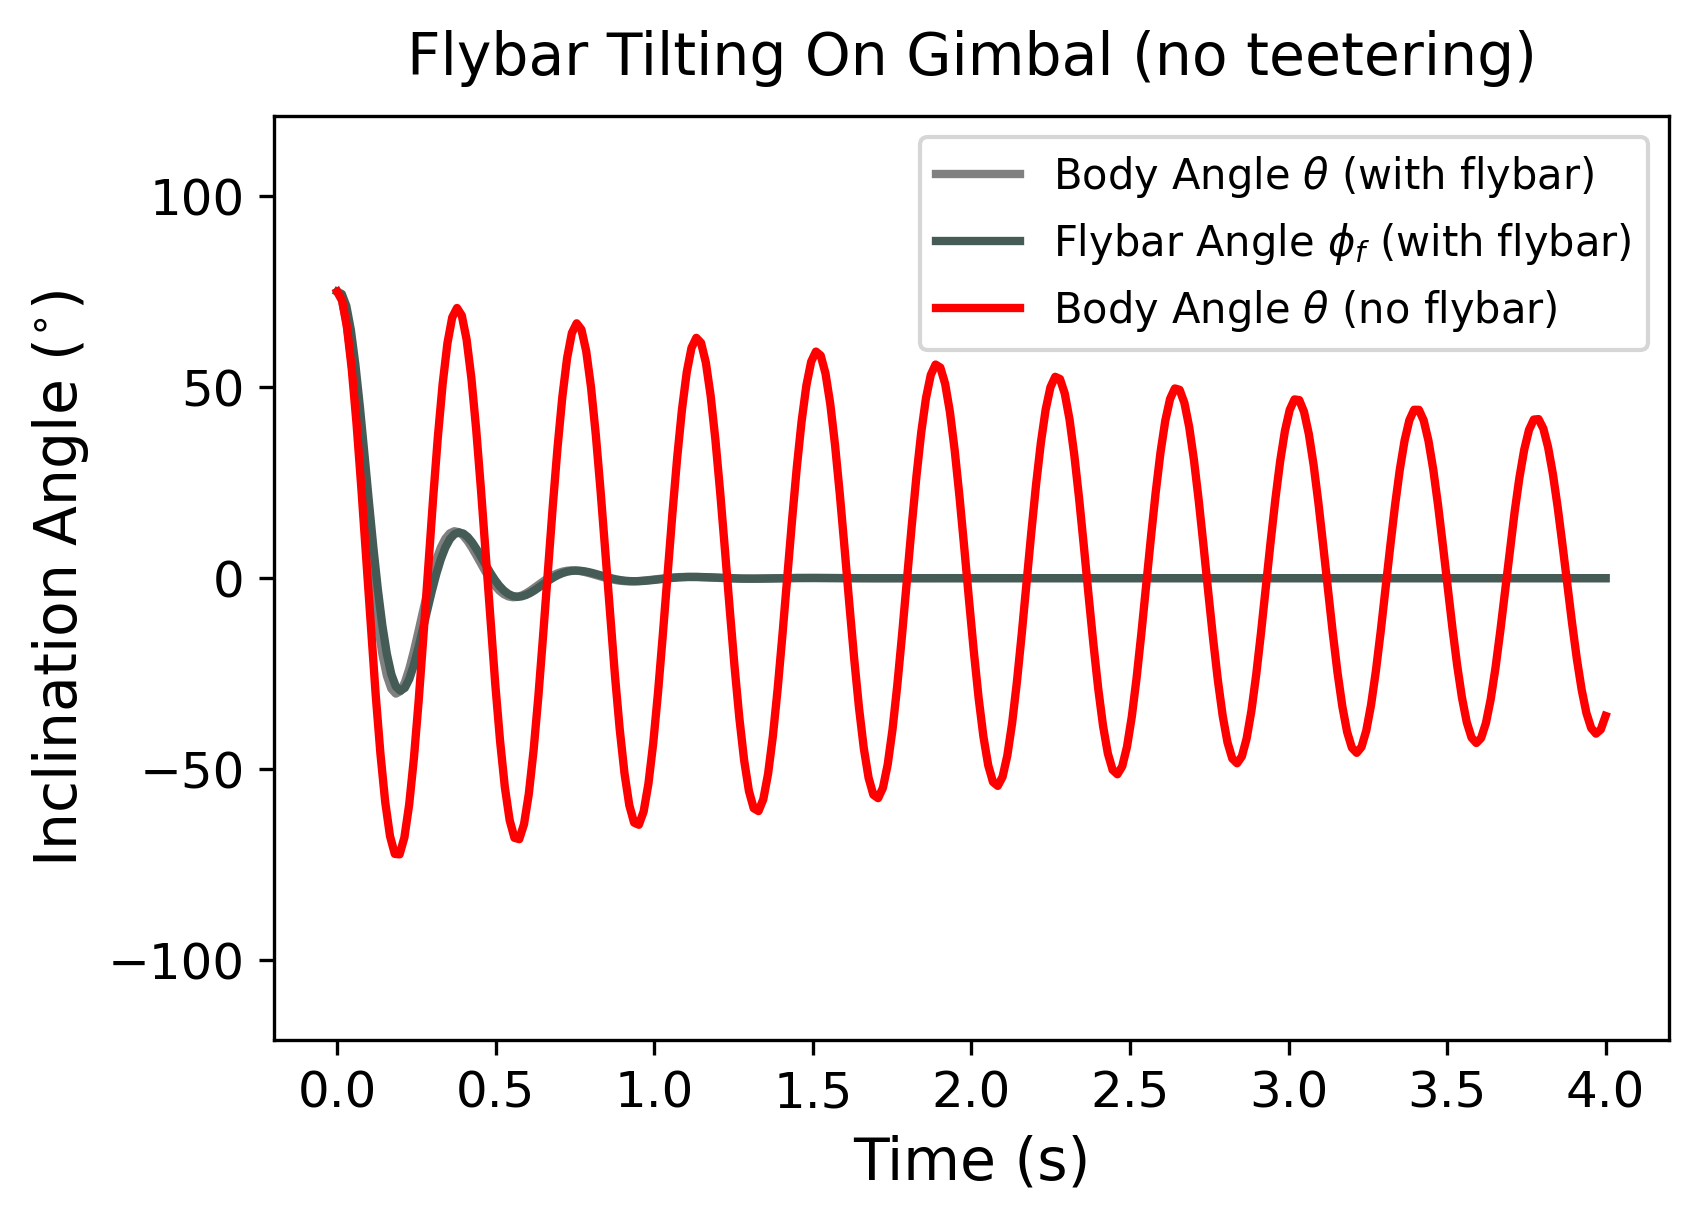

In [ ]:
pgimbal_noteeter = pgimbal.copy()
l_counterweight = 30e-3
m_counterweight = 144e-6
pgimbal_noteeter.J = pgimbal_noteeter.J + m_counterweight * l_counterweight**2 # add mass of counterweight
pgimbal_noteeter.c = pgimbal_noflybar.c
pgimbal_noteeter.k_1 = 700 * pgimbal_noteeter.J # strength of feathering effect
pgimbal_noteeter.k_2 = 80 # rate of return flybar angle to body angle
pgimbal_noteeter.k_3 = pgimbal.k_3 + m_counterweight * p.g * l_counterweight

# Kyle to add: pgimbal_noteeter_noflybar case that incorporates the counterweight.
pgimbal_noteeter_noflybar = pgimbal_noflybar.copy()
pgimbal_noteeter_noflybar.J = pgimbal_noteeter.J # same moment of inertia
pgimbal_noteeter_noflybar.c = pgimbal_noteeter.c # same rotational damping coeff due to rigid rotor
pgimbal_noteeter_noflybar.k_1 = 0 # no torque on body due to feathering
pgimbal_noteeter_noflybar.k_3 = pgimbal_noteeter.k_3 # same restoring torque as flybar case

Agimbal_noteeter_n = to_numeric(Agimbal_noteeter, pgimbal_noteeter)
print(f'eigenvalues: {np.linalg.eig(Agimbal_noteeter_n).eigenvalues}')
sys_gimbal_noteeter = ct.ss(Agimbal_noteeter_n, np.zeros(3), np.eye(3), 0,
                            outputs=[r'$\theta$',r'$\omega$',r'$\phi$'],
                            name='gimbal no teetering')
ct.damp(sys_gimbal_noteeter)
_response = ct.initial_response(sys_gimbal_noteeter, X0=X0_gimbal, T=4)
# look at difference of two to compare to video, which shows a 11.2 deg angle difference when gimbal is around 7 deg
idx = 7#11 # approximate moment gimbal is at 7 deg
print(f'angle comparison from video. gimbal angle={np.rad2deg(_response.x[0,idx])}, flybar angle={np.rad2deg(_response.x[2,idx])}, difference: {np.rad2deg(_response.x[2,idx]-_response.x[0,idx])}')
Agimbal_noteeter_noflybar_n = to_numeric(Agimbal_noteeter, pgimbal_noteeter_noflybar)
print(f'eigenvalues: {np.linalg.eig(Agimbal_noteeter_noflybar_n).eigenvalues}')
sys_gimbal_noteeter_noflybar = ct.ss(Agimbal_noteeter_noflybar_n, np.zeros(3), np.eye(3), 0,
                            outputs=[r'$\theta$',r'$\omega$',r'$\phi$'],
                            name='gimbal no teetering')
ct.damp(sys_gimbal_noteeter_noflybar)

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(_response.time, _response.x[0,:] * 180 / np.pi, color='grey',
        label=r'Body Angle $\theta$ (with flybar)', linewidth=2, zorder=1)
plt.plot(_response.time, _response.x[2,:] * 180 / np.pi, color='#455b55',
        label=r'Flybar Angle $\phi_f$ (with flybar)', linewidth=2, zorder=2)
_response = ct.initial_response(sys_gimbal_noteeter_noflybar, X0=X0_gimbal, T=4)
#_response = ct.initial_response(sys_gimbal_noflybar, X0=X0_gimbal, T=4)
plt.plot(_response.time, _response.x[0,:] * 180 / np.pi, linewidth=2, color='red',
        label=r'Body Angle $\theta$ (no flybar)', zorder=3)
plt.legend()
plt.ylim(-121, 121)
plt.ylabel(r'Inclination Angle $(^{\circ})$', fontsize=14)
plt.xlabel('Time (s)', fontsize=14)
plt.title('Flybar Tilting On Gimbal (no teetering)', fontsize=14, pad=10)
plt.xticks(np.arange(0, 4.5, 0.5), fontsize=12)
plt.yticks(fontsize=12);


Simulate free-flight system with non-teetering rotor and gimbal-derived parameters from IROS2023 data.

eigenvalues: [-75.96602253+0.j         -5.81595614+0.j          0.73718515+2.9240833j
   0.73718515-2.9240833j]


Text(0.5, 0.98, '')

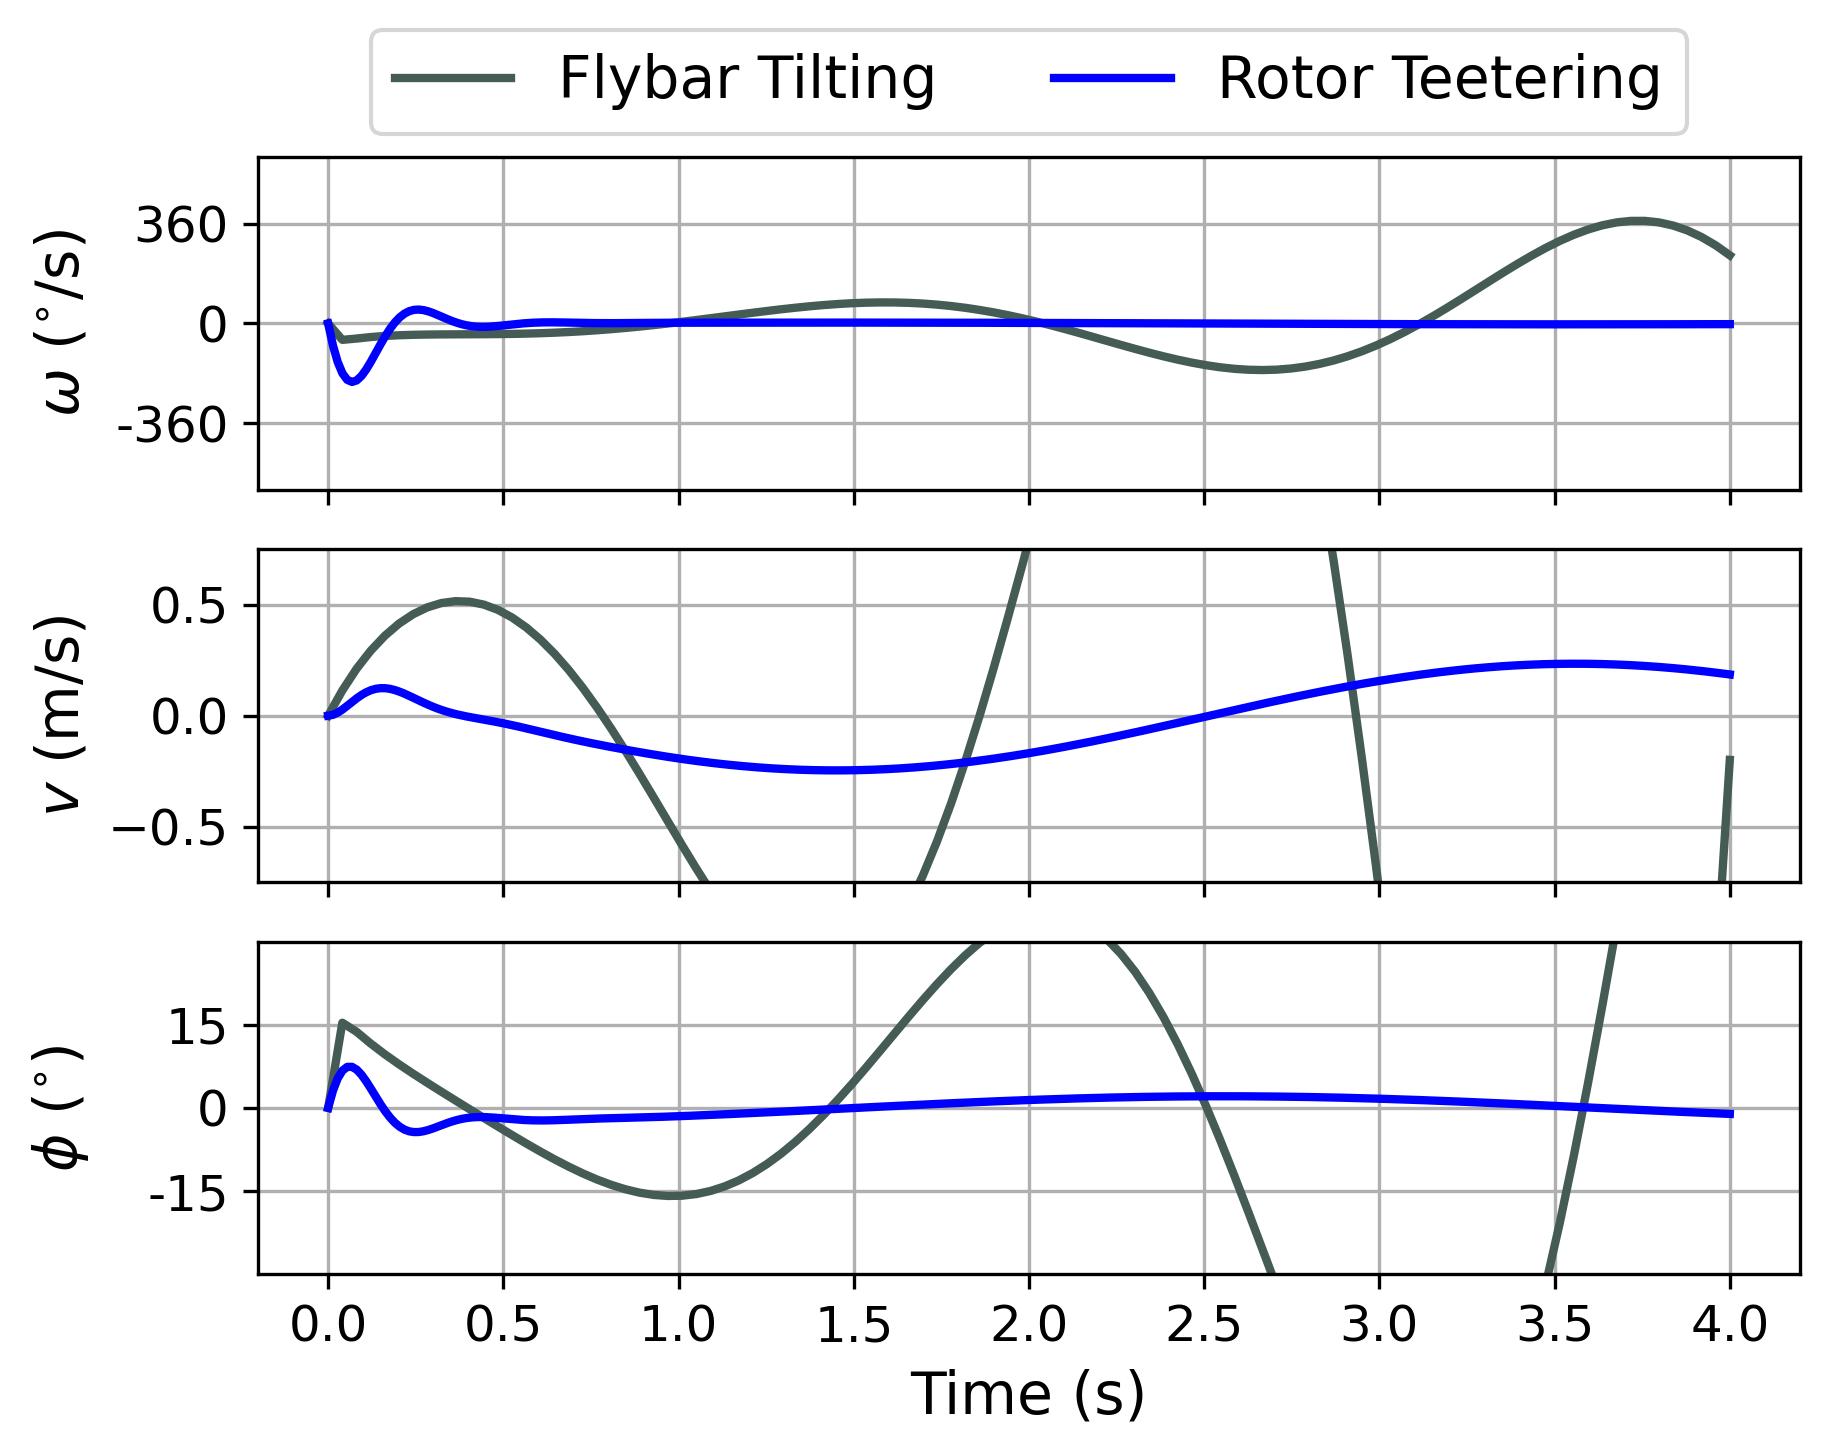

In [ ]:
p_noteeter = p.copy()
p_noteeter.k_1 = pgimbal_noteeter.k_1 # * 5 # uncomment out '*5' to see how much gain necessary to stabilize
p_noteeter.k_2 = pgimbal_noteeter.k_2
p_noteeter.c = pgimbal_noteeter.c
A_noteeter_n = to_numeric(A_noteeter, p_noteeter)
print(f'eigenvalues: {np.linalg.eig(A_noteeter_n).eigenvalues}')

sys_noteeter = ct.ss(
    A_noteeter_n, B, C, D,
    outputs=[r'$\theta$', r'$\omega$', '$v$', r'$\phi$'],
    name='noteeter')

fig = plt.figure(figsize=(6,6), dpi=300)
ct.initial_response(sys_noteeter, X0=X0, T=4).plot()
ct.initial_response(sys, X0=X0, T=4).plot()
degps_formatter = FuncFormatter(lambda y, _: f'{np.rad2deg(y):.0f}')
deg_formatter = FuncFormatter(lambda y, _: f'{np.rad2deg(y):.0f}')

# removes the theta subplot
axs = plt.gcf().get_axes()
axs[0].remove()

for i, _ax in enumerate(plt.gcf().get_axes()):
    lines = _ax.get_lines()
    for line in lines:
        line.set_linewidth(2)
    if len(lines) >= 2:
        lines[1].set_color('blue')   # Teetering
        lines[0].set_color('#455b55')   # Flybar Tilting
    if i == 0:
        _ax.legend(
            ["Flybar Tilting", "Rotor Teetering"],
            loc='upper center',
            bbox_to_anchor=(0.5, 1.4),
            ncol=2,
            fontsize=14,
            borderaxespad=0.1
        )
    #     _ax.set_ylim(np.deg2rad(-45), np.deg2rad(45))
    #     _ax.set_yticks(np.deg2rad(np.arange(-30, 31, 30)))
    #     _ax.yaxis.set_major_formatter(deg_formatter)
    #     _ax.set_ylabel(r'$\theta$ ($^{\circ}$)')
    # elif i == 1:
        _ax.set_ylim(np.deg2rad(-600), np.deg2rad(600))
        _ax.set_yticks(np.deg2rad(np.arange(-360, 361, 360)))
        _ax.yaxis.set_major_formatter(degps_formatter)
        _ax.set_ylabel(r'$\omega$ ($^{\circ}$/s)')
    elif i == 1:
        _ax.set_ylim(-0.75, 0.75)
        _ax.set_ylabel(r'$v$ (m/s)')
    elif i == 2:
        _ax.set_ylim(np.deg2rad(-30), np.deg2rad(30))
        _ax.set_yticks(np.deg2rad(np.arange(-15, 16, 15)))
        _ax.yaxis.set_major_formatter(deg_formatter)
        _ax.set_ylabel(r'$\phi$ ($^{\circ}$)', fontsize=14)
        _ax.set_xlabel("Time (s)", fontsize=14)
    _ax.grid()
    _ax.tick_params(axis='both', which='major', labelsize=12)
    _ax.set_ylabel(_ax.get_ylabel(), fontsize=14)
plt.suptitle('')
# plt.savefig('/content/gdrive/My Drive/Coin-copter/Simulations/flybar_tilting_comparison.pdf')

eigenvalues: [-75.96602253+0.j         -5.81595614+0.j          0.73718515+2.9240833j
   0.73718515-2.9240833j]


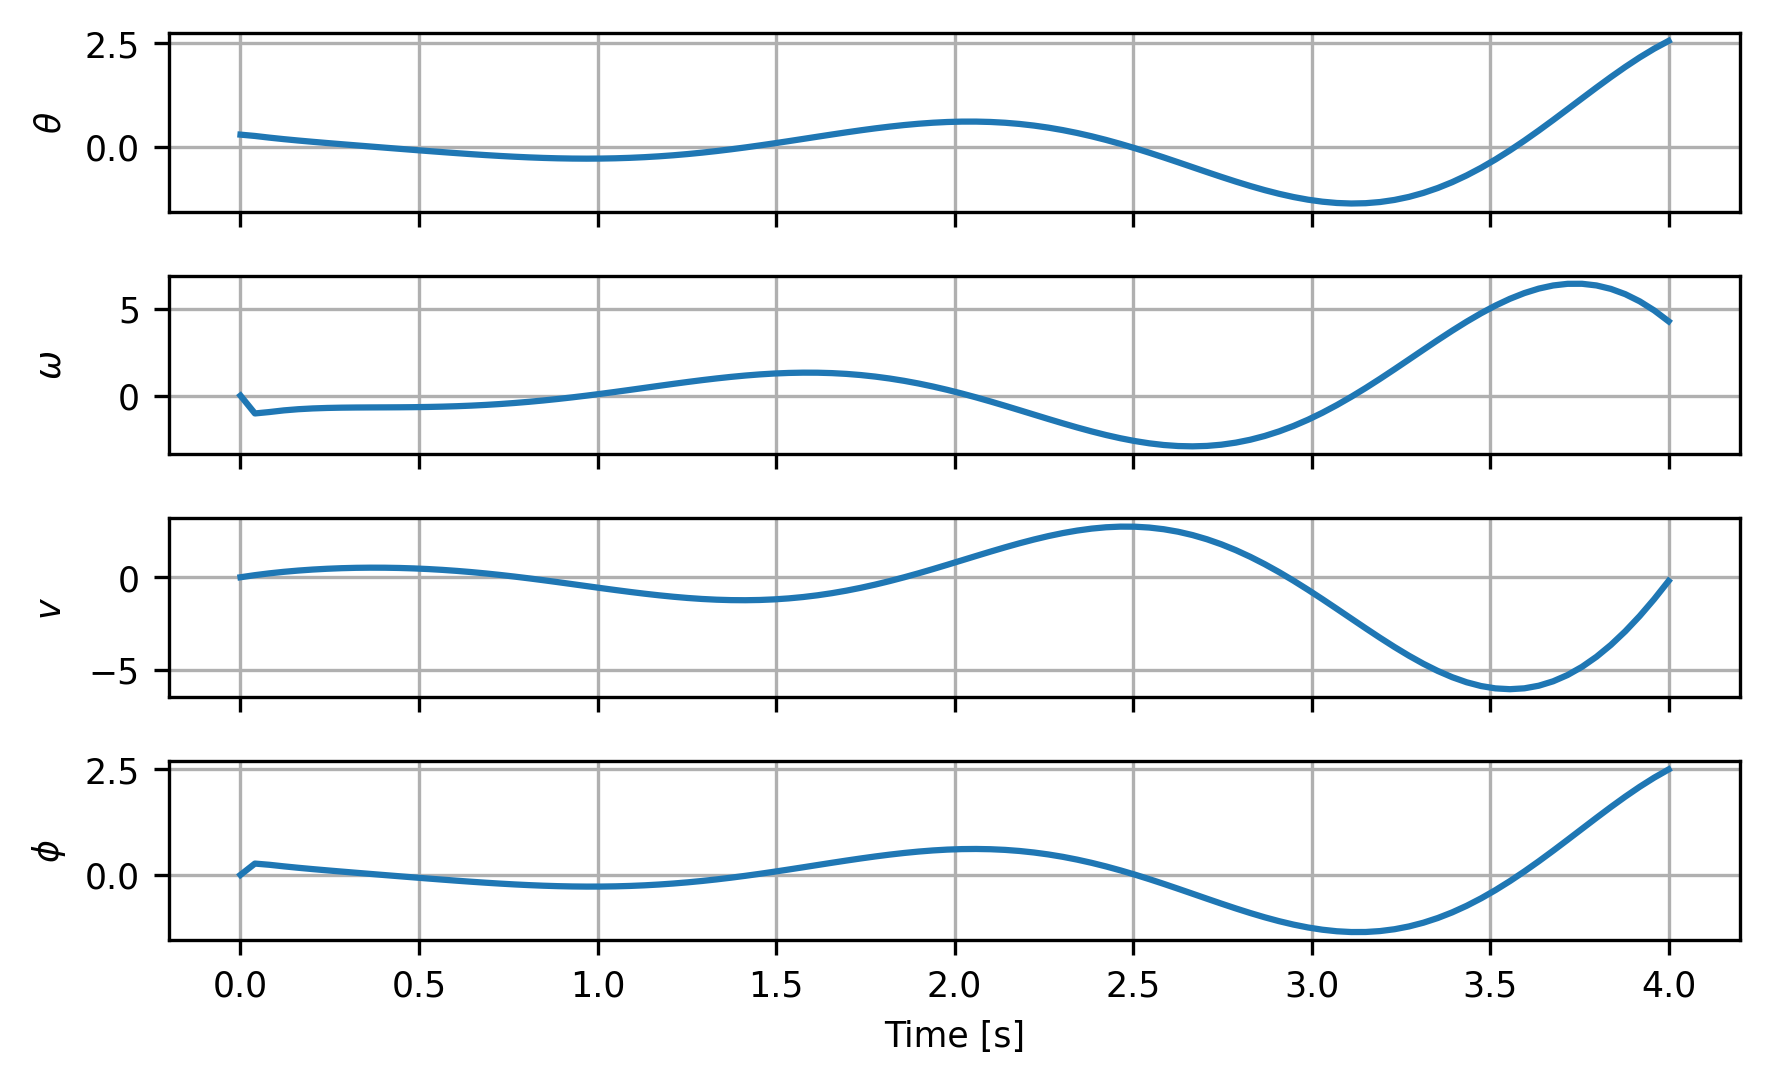

In [ ]:
################################################
############### SAWYER'S OLD CODE ##############
################################################
p_noteeter = p.copy()
p_noteeter.k_1 = pgimbal_noteeter.k_1 #* 3 # un-comment multiply factor at end to obtain stability
p_noteeter.k_2 = pgimbal_noteeter.k_2
p_noteeter.c = pgimbal_noteeter.c
A_noteeter_n = to_numeric(A_noteeter, p_noteeter)
print(f'eigenvalues: {np.linalg.eig(A_noteeter_n).eigenvalues}')
sys_noteeter = ct.ss(A_noteeter_n, B, C, D,
            outputs=[r'$\theta$',r'$\omega$','$v$',r'$\phi$'],
            name='noteeter')
fig = plt.figure(figsize=(6,4), dpi=300)
_response = ct.initial_response(sys_noteeter, X0=X0, T=4)
_response.plot()
for ax in plt.gcf().get_axes():
  ax.grid()
plt.suptitle('');

eigenvalues: [-75.96602253+0.j         -5.81595614+0.j          0.73718515+2.9240833j
   0.73718515-2.9240833j]


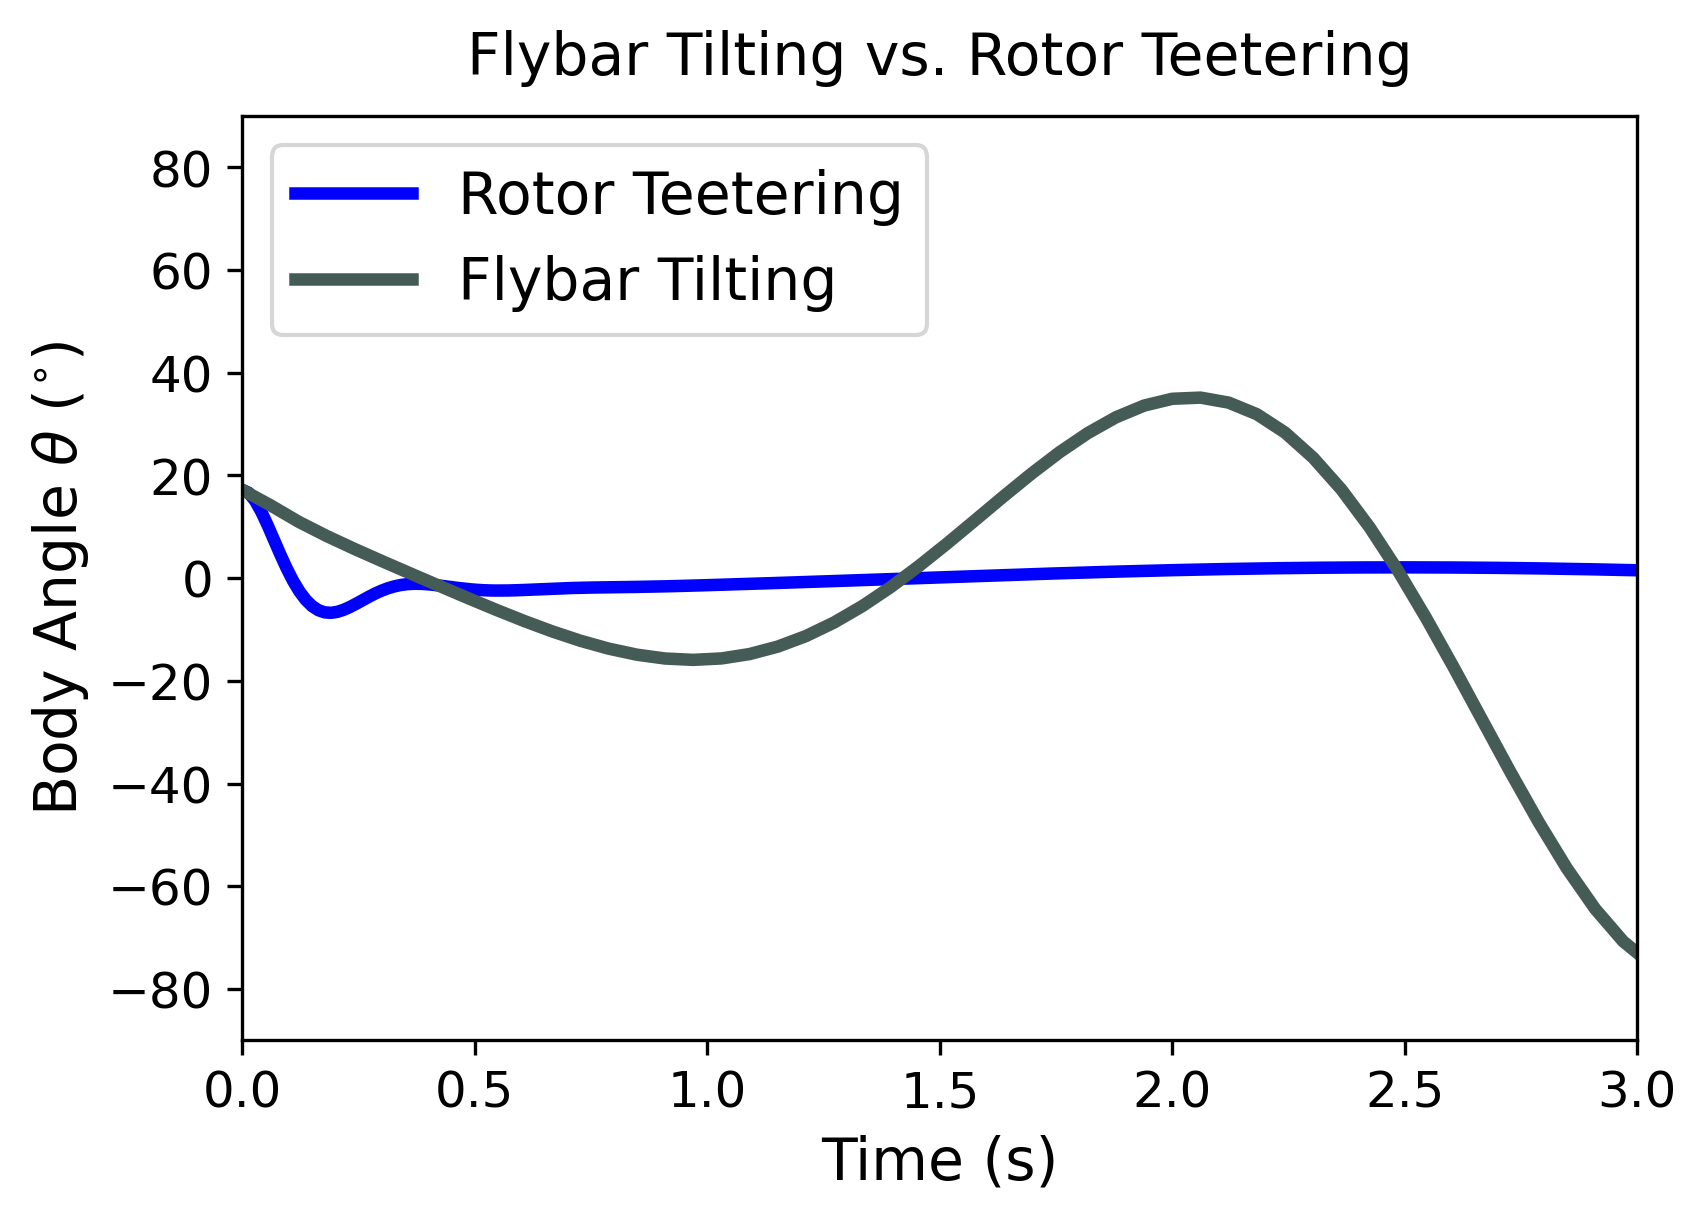

In [ ]:
p_noteeter = p.copy()
p_noteeter.k_1 = pgimbal_noteeter.k_1
p_noteeter.k_2 = pgimbal_noteeter.k_2
p_noteeter.c = pgimbal_noteeter.c
A_noteeter_n = to_numeric(A_noteeter, p_noteeter)
print(f'eigenvalues: {np.linalg.eig(A_noteeter_n).eigenvalues}')
sys_noteeter = ct.ss(
    A_noteeter_n, B, C, D,
    outputs=[r'$\theta$', r'$\omega$', '$v$', r'$\phi$'],
    name='noteeter'
)

fig = plt.figure(figsize=(6,4), dpi=300) # Adjust figure size for a single plot
ax = fig.add_subplot(111) # Add a single subplot

# Get response data for both cases
response = ct.initial_response(sys, X0=X0, T=6)
response_noteeter = ct.initial_response(sys_noteeter, X0=X0, T=6)

# Plot theta for 'Flybar' in degrees
ax.plot(response.time, response.x[0,:] * 180 / np.pi, color='blue', linewidth=3, label='Rotor Teetering')
# Plot theta for 'No Flybar' in degrees
ax.plot(response_noteeter.time, response_noteeter.x[0,:] * 180 / np.pi, color='#455b55', linewidth=3, label='Flybar Tilting')
plt.title('Flybar Tilting vs. Rotor Teetering', fontsize=14, pad=10)
ax.legend(loc='upper left', fontsize=14, facecolor='white') # Increase legend font size and set background
ax.set_xlim(0, 3) # Show only the first 1 second
ax.set_ylim(-90, 90) # Example limits for theta in degrees, adjust as needed
ax.set_ylabel(r'Body Angle $\theta$ $(^{\circ})$', fontsize=14) # Increase y-label font size
ax.set_xlabel('Time (s)', fontsize=14) # Increase x-label font size
# ax.grid()
ax.tick_params(axis='both', which='major', labelsize=12) # Tick label font size (kept at 12)
plt.show()

In [ ]:
# !wget -nc https://raw.githubusercontent.com/brpy/colab-pdf/master/colab_pdf.py
# from colab_pdf import colab_pdf
# import os
# # Change the current working directory to a specific folder in your Drive
# os.chdir('/content/drive/My Drive/University of Washington/UW_Research/Projects/Coin-copter/Science_Robotics_2025/Figures/Supplementary_Media/Sawyer-Simulation-plots')
# colab_pdf('/content/drive/My Drive/University of Washington/UW_Research/Projects/Coin-copter/Science_Robotics_2025/Figures/Supplementary_Media/Sawyer-Simulation-plots/Coin-Copter_dynamics4.ipynb')

In [ ]:
!jupyter nbconvert --to pdf Coin-Copter_dynamics4.ipynb
!ls -lh /content/*.pdf

[NbConvertApp] WARNING | pattern 'Coin-Copter_dynamics4.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--e